 # Hands-on Exercise 3: Loan Approval Classification
 Name : Tanishtha Papadkar
 Class: CIS 508

## High-Level Outline and Brief Background

### What is the problem?
The goal of this project is to build a machine learning model that predicts whether a loan application will be approved. This is a classification problem because the target variable `approved` has two possible outcomes.

### Why is it important?
Loan approval decisions directly impact a bank’s profitability, risk exposure, and customer satisfaction. A good predictive model can speed up decision-making, reduce manual work, and improve consistency.

### Who are the key stakeholders?
- Bank management (profit and risk)
- Loan officers (decision support)
- Customers (fair and fast decisions)
- Compliance/legal teams (fair lending practices)

### Ethical considerations
Some variables (e.g., age, ethnicity) may introduce bias. Even if available, they must be used cautiously to avoid discrimination and ensure fairness in decision-making.

## 1. Load Libraries

This step imports all necessary libraries for data analysis, visualization, preprocessing, modeling, and evaluation.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 2. Load the Data

This step loads the dataset and displays the first few rows to verify that the data was read correctly.

In [4]:
# Upload and load data
from google.colab import files
uploaded = files.upload()

Saving loan_approval.csv to loan_approval.csv


In [5]:
df = pd.read_csv("loan_approval.csv")

print("Shape of dataset:", df.shape)
display(df.head())

Shape of dataset: (690, 17)


,approved,gender,age,debt,married,bank_customer,ethnicity_white,ethnicity_black,ethnicity_latino,ethnicity_asian,ethnicity_other,years_employed,prior_default,employed,credit_score,drivers_license,Income
0,1,1,30.83,0.000,1,1,1,0,0,0,0,1.25,1,1,1,0,0
1,1,0,58.67,4.460,1,1,0,1,0,0,0,3.04,1,1,6,0,560
2,1,0,24.50,0.500,1,1,0,1,0,0,0,1.50,1,0,0,0,824
3,1,1,27.83,1.540,1,1,1,0,0,0,0,3.75,1,1,5,1,3
4,1,1,20.17,5.625,1,1,1,0,0,0,0,1.71,1,0,0,0,0


## 3. Basic Data Check

This step examines the dataset structure, including column names, data types, and summary statistics.

In [6]:
print("Columns:")
print(df.columns.tolist())

print("\nData info:")
print(df.info())

print("\nSummary statistics:")
display(df.describe(include="all"))

Columns:
['approved', 'gender', 'age', 'debt', 'married', 'bank_customer', 'ethnicity_white', 'ethnicity_black', 'ethnicity_latino', 'ethnicity_asian', 'ethnicity_other', 'years_employed', 'prior_default', 'employed', 'credit_score', 'drivers_license', 'Income']

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   approved          690 non-null    int64  
 1   gender            690 non-null    int64  
 2   age               690 non-null    float64
 3   debt              690 non-null    float64
 4   married           690 non-null    int64  
 5   bank_customer     690 non-null    int64  
 6   ethnicity_white   690 non-null    int64  
 7   ethnicity_black   690 non-null    int64  
 8   ethnicity_latino  690 non-null    int64  
 9   ethnicity_asian   690 non-null    int64  
 10  ethnicity_other   690 non-null    int64  
 11  year

,approved,gender,age,debt,married,bank_customer,ethnicity_white,ethnicity_black,ethnicity_latino,ethnicity_asian,ethnicity_other,years_employed,prior_default,employed,credit_score,drivers_license,Income
count,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.00000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.00000,690.000000,690.000000
mean,0.444928,0.695652,31.514116,4.758725,0.760870,0.763768,0.591304,0.20000,0.082609,0.085507,0.040580,2.223406,0.523188,0.427536,2.40000,0.457971,1017.385507
std,0.497318,0.460464,11.860245,4.978163,0.426862,0.425074,0.491949,0.40029,0.275490,0.279838,0.197458,3.346513,0.499824,0.495080,4.86294,0.498592,5210.102598
min,0.000000,0.000000,13.750000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,0.000000,0.000000,22.670000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.165000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,0.000000,1.000000,28.460000,2.750000,1.000000,1.000000,1.000000,0.00000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.00000,0.000000,5.000000
75%,1.000000,1.000000,37.707500,7.207500,1.000000,1.000000,1.000000,0.00000,0.000000,0.000000,0.000000,2.625000,1.000000,1.000000,3.00000,1.000000,395.500000
max,1.000000,1.000000,80.250000,28.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,28.500000,1.000000,1.000000,67.00000,1.000000,100000.000000


## 4. Target Variable Analysis

This step analyzes the distribution of the target variable `approved` to check for class imbalance.

Target counts:
approved
0    383
1    307
Name: count, dtype: int64

Target proportions:
approved
0    0.555072
1    0.444928
Name: proportion, dtype: float64


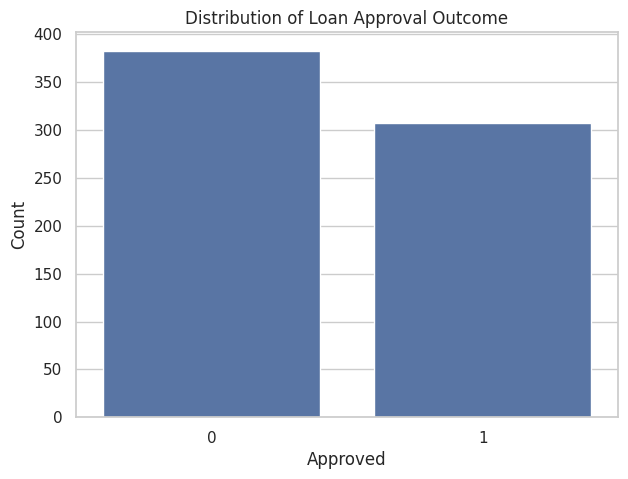

In [7]:
target_col = "approved"

print("Target counts:")
print(df[target_col].value_counts(dropna=False))

print("\nTarget proportions:")
print(df[target_col].value_counts(normalize=True, dropna=False))

plt.figure(figsize=(7, 5))
sns.countplot(x=target_col, data=df)
plt.title("Distribution of Loan Approval Outcome")
plt.xlabel("Approved")
plt.ylabel("Count")
plt.show()

### Interpretation of Target Distribution

The distribution of the target variable `approved` shows that there are slightly more rejected applications (class 0) than approved ones (class 1). Specifically, about 55.5% of applications are rejected and 44.5% are approved.

This indicates that the dataset is relatively balanced, although there is a slight class imbalance. This is important because highly imbalanced datasets can bias models toward the majority class. In this case, the imbalance is mild and should not significantly affect model performance.

## 5. Missing Values Check

This step checks for missing values across all columns in the dataset.

In [8]:
missing = df.isnull().sum().sort_values(ascending=False)
print("Missing values by column:")
print(missing)

Missing values by column:
approved            0
gender              0
age                 0
debt                0
married             0
bank_customer       0
ethnicity_white     0
ethnicity_black     0
ethnicity_latino    0
ethnicity_asian     0
ethnicity_other     0
years_employed      0
prior_default       0
employed            0
credit_score        0
drivers_license     0
Income              0
dtype: int64


### Interpretation of Missing Values

The dataset contains no missing values across any of the features. This confirms that the dataset has already been preprocessed and cleaned.

Because there are no missing values, no imputation techniques are required. This simplifies the modeling process and ensures that all available data can be used directly for training the models.

## 6. Feature and Target Separation

This step separates the dataset into input features (X) and the target variable (y).

In [9]:
X = df.drop(columns=[target_col])
y_raw = df[target_col]

# Encode the target if it is not already numeric
if y_raw.dtype == "object" or str(y_raw.dtype).startswith("category"):
    le_target = LabelEncoder()
    y = le_target.fit_transform(y_raw.astype(str))
    print("Target classes:", list(le_target.classes_))
else:
    y = y_raw.copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (690, 16)
Target shape: (690,)


## 7. Identify Feature Types

This step separates numeric and categorical variables for proper preprocessing and analysis.

In [10]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['gender', 'age', 'debt', 'married', 'bank_customer', 'ethnicity_white', 'ethnicity_black', 'ethnicity_latino', 'ethnicity_asian', 'ethnicity_other', 'years_employed', 'prior_default', 'employed', 'credit_score', 'drivers_license', 'Income']

Categorical features:
[]


## 8. Exploratory Data Analysis (Numeric Features)

This step visualizes the distribution of numeric variables to understand their spread and detect scaling issues.

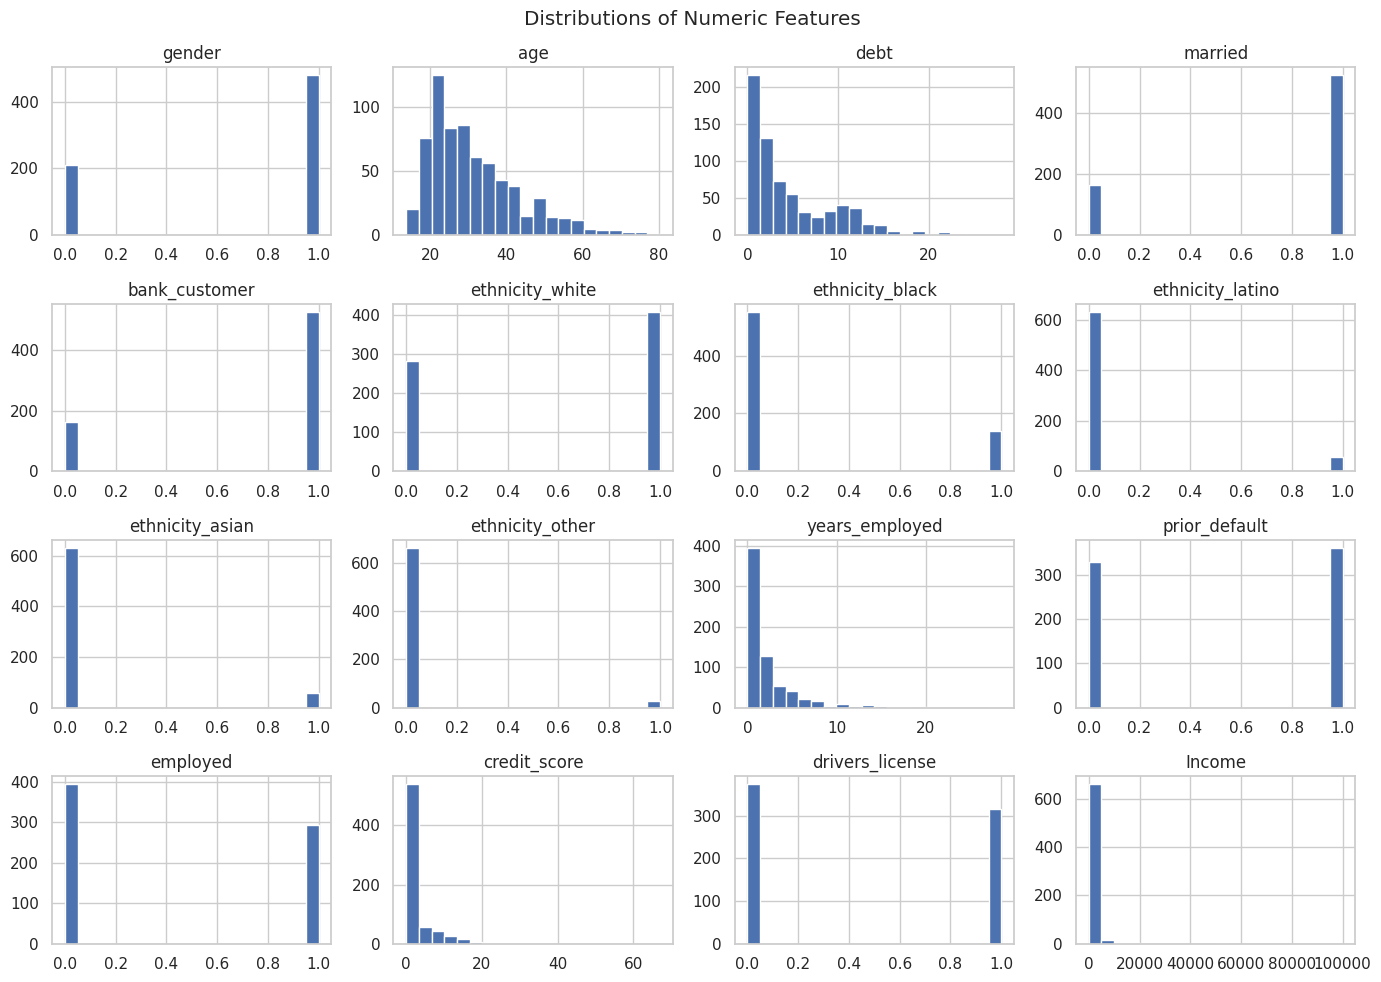

In [11]:
if len(numeric_features) > 0:
    X[numeric_features].hist(bins=20, figsize=(14, 10))
    plt.suptitle("Distributions of Numeric Features")
    plt.tight_layout()
    plt.show()
else:
    print("No numeric features found.")

### Interpretation of Numeric Feature Distributions

The histograms show the distribution of numeric variables in the dataset. Several variables, such as `debt`, `years_employed`, and `income`, appear to be right-skewed, meaning most values are concentrated at lower levels with a few higher outliers.

Other variables, such as binary features (e.g., `gender`, `married`, `bank_customer`), show discrete distributions as expected.

These observations are important because skewed variables may benefit from scaling or transformation. In this project, scaling was applied using StandardScaler to ensure that features are on a comparable scale, especially for models like KNN and SVM that are sensitive to distance.

## 9. Correlation Analysis

This step creates a heatmap to examine relationships between numeric variables and the target.

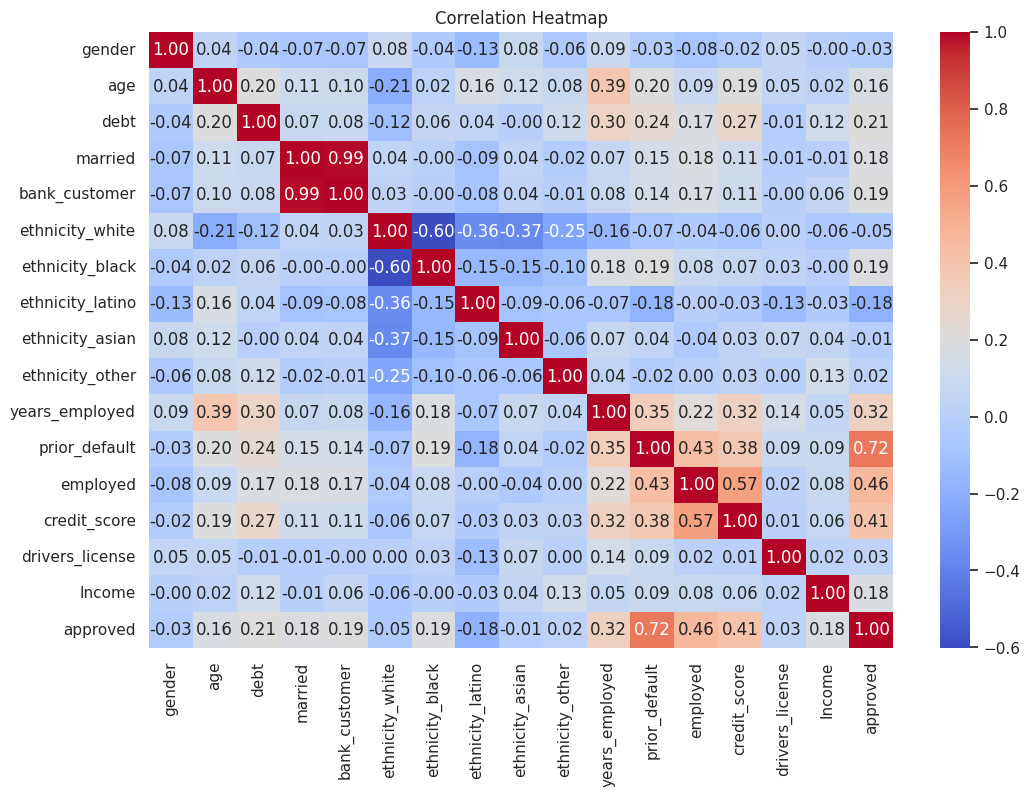

In [12]:
if len(numeric_features) > 1:
    corr_df = df[numeric_features].copy()
    corr_df[target_col] = y
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr_df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Heatmap")
    plt.show()
else:
    print("Not enough numeric features for a correlation heatmap.")

### Interpretation of Correlation Heatmap

The correlation heatmap shows the relationships between features and the target variable `approved`.

The strongest positive relationships with loan approval are:
- `prior_default` (~0.72)
- `employed` (~0.46)
- `credit_score` (~0.41)

This suggests that applicants with no prior defaults, stable employment, and higher credit scores are more likely to be approved.

Most other variables show weak correlations, indicating that loan approval decisions are influenced by a combination of factors rather than a single variable.

It is also important to note that some variables, such as ethnicity-related features, should be treated carefully due to ethical and regulatory concerns.

## 10. Exploratory Data Analysis (Categorical Features)

This step visualizes the distribution of categorical variables using bar charts.

In [13]:
for col in categorical_features:
    plt.figure(figsize=(8, 4))
    df[col].value_counts().plot(kind="bar")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 11. Train-Test Split

This step splits the dataset into training and testing sets while maintaining class balance.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (552, 16)
Testing set shape: (138, 16)


## 12. Data Preprocessing

This step builds preprocessing pipelines:
- Scaling for numeric variables
- Encoding for categorical variables

In [15]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

## 13. Helper Functions

This step defines reusable functions for:
- Displaying hyperparameter tuning results
- Plotting performance
- Evaluating models (confusion matrix, ROC, etc.)
-k FOLD

In [16]:
def display_grid_results(grid, param_1, param_2, title):
    results = pd.DataFrame(grid.cv_results_)
    show_cols = ["params", "mean_test_score", "rank_test_score"]
    print(f"\n{title} - All parameter combinations:")
    display(results[show_cols].sort_values(by="mean_test_score", ascending=False))

    labels = []
    scores = []
    for params, score in zip(results["params"], results["mean_test_score"]):
        labels.append(f"{params[param_1]}, {params[param_2]}")
        scores.append(score)

    plt.figure(figsize=(12, 5))
    plt.plot(labels, scores, marker="o")
    plt.xticks(rotation=45, ha="right")
    plt.title(f"{title} - Grid Search Scores")
    plt.xlabel("Parameter Combination")
    plt.ylabel("Cross-Validated Score")
    plt.tight_layout()
    plt.show()


def evaluate_best_model(model, X_test, y_test, model_name, cv_k=5):
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    cm = confusion_matrix(y_test, y_pred)
    print(f"\n{model_name} Confusion Matrix:")
    print(cm)

    print(f"\n{model_name} Classification Report:")
    print(classification_report(y_test, y_pred))

    auc = roc_auc_score(y_test, y_score)
    print(f"{model_name} ROC AUC: {auc:.4f}")

    fpr, tpr, thresholds = roc_curve(y_test, y_score)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.4f})")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend()
    plt.show()

    cv = KFold(n_splits=cv_k, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")
    print(f"{model_name} {cv_k}-Fold CV ROC AUC Scores:", cv_scores)
    print(f"{model_name} Mean CV ROC AUC: {cv_scores.mean():.4f}")

    return {
        "model_name": model_name,
        "confusion_matrix": cm,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": auc,
        "cv_mean_auc": cv_scores.mean()
    }

## 14. Logistic Regression: Hyperparameter Tuning

This step uses GridSearchCV to find the best parameters for Logistic Regression.

Best Logistic Regression Parameters:
{'clf__C': 10, 'clf__solver': 'newton-cg'}
Best Logistic Regression CV Score:
0.9143648431345041

Logistic Regression - All parameter combinations:


,params,mean_test_score,rank_test_score
14,"{'clf__C': 10, 'clf__solver': 'liblinear'}",0.914365,1
12,"{'clf__C': 10, 'clf__solver': 'newton-cg'}",0.914365,1
13,"{'clf__C': 10, 'clf__solver': 'lbfgs'}",0.914365,1
16,"{'clf__C': 100, 'clf__solver': 'lbfgs'}",0.913767,4
17,"{'clf__C': 100, 'clf__solver': 'liblinear'}",0.913766,5
15,"{'clf__C': 100, 'clf__solver': 'newton-cg'}",0.913700,6
11,"{'clf__C': 1, 'clf__solver': 'liblinear'}",0.913567,7
9,"{'clf__C': 1, 'clf__solver': 'newton-cg'}",0.913500,8
10,"{'clf__C': 1, 'clf__solver': 'lbfgs'}",0.913500,8
8,"{'clf__C': 0.1, 'clf__solver': 'liblinear'}",0.910506,10


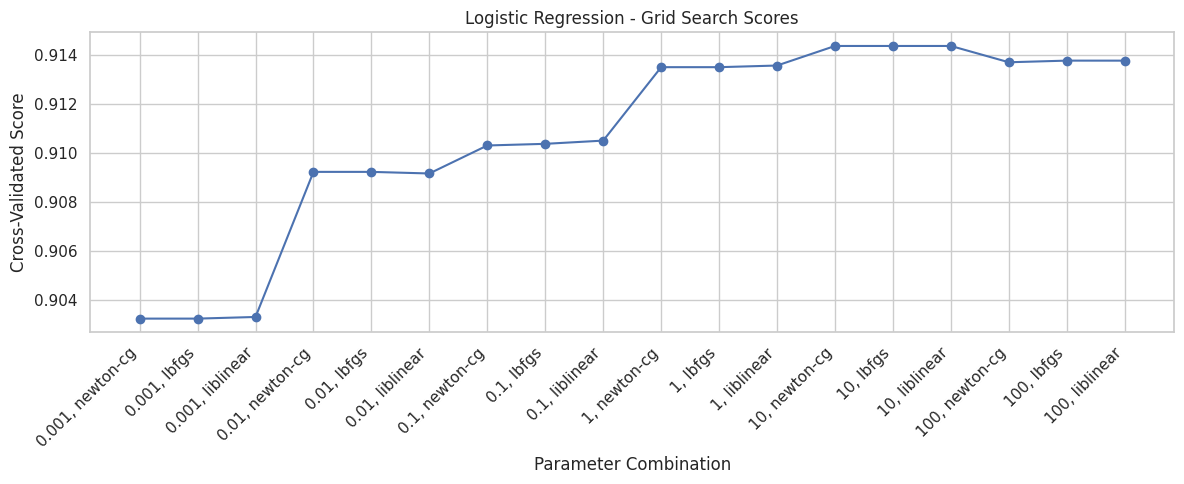

In [17]:
log_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(max_iter=2000))
])

log_param_grid = {
    "clf__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "clf__solver": ["newton-cg", "lbfgs", "liblinear"]
}

log_grid = GridSearchCV(
    log_pipe,
    param_grid=log_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

log_grid.fit(X_train, y_train)

print("Best Logistic Regression Parameters:")
print(log_grid.best_params_)
print("Best Logistic Regression CV Score:")
print(log_grid.best_score_)

display_grid_results(log_grid, "clf__C", "clf__solver", "Logistic Regression")

### Interpretation of Hyperparameter Tuning (Logistic Regression)

The grid search results show how the regularization parameter **C** and solver choice affect model performance.

The best performance is achieved at **C = 10**, where all three solvers (newton-cg, lbfgs, and liblinear) produce the same highest ROC AUC score of approximately **0.9144**. This indicates that the model is not sensitive to the choice of solver, and performance is primarily driven by the regularization strength.

A clear pattern is observed across different values of C:
- Very small values (e.g., C = 0.001) result in significantly lower performance (~0.903), indicating **over-regularization and underfitting**
- Increasing C improves performance, with the best results at C = 10
- Further increasing C to 100 does not improve performance and slightly reduces it, suggesting diminishing returns

This pattern shows that **moderate regularization provides the best balance between bias and variance**.

Additionally, the cross-validation scores (mean ROC AUC ≈ 0.9175) are relatively stable, indicating that the model generalizes well across different subsets of the data.

Overall, the results confirm that **C = 10 is the optimal choice**, providing strong and stable performance without overfitting.

## 15. Logistic Regression: Model Evaluation

This step evaluates the best Logistic Regression model using:
- Confusion Matrix
- Classification Report
- ROC Curve and AUC
- K-Fold Cross Validation

In [34]:
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.model_selection import KFold, cross_val_score
import matplotlib.pyplot as plt

def evaluate_model_pretty(model, X_test, y_test, model_name="Model", cv_k=5):

    print(f"\n{'='*60}")
    print(f"MODEL EVALUATION: {model_name}".center(60))
    print(f"{'='*60}\n")

    # Predictions
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    # -----------------------------
    # CONFUSION MATRIX
    # -----------------------------
    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(cm,
                         index=["Actual 0", "Actual 1"],
                         columns=["Predicted 0", "Predicted 1"])

    print("CONFUSION MATRIX:")
    display(cm_df)

    # -----------------------------
    # CLASSIFICATION REPORT TABLE
    # -----------------------------
    report_dict = classification_report(y_test, y_pred, output_dict=True)
    report_df = pd.DataFrame(report_dict).transpose()

    print("\nCLASSIFICATION REPORT:")
    display(report_df.style
            .format("{:.3f}")
            .set_properties(**{'font-weight': 'bold'})
            .set_caption(f"{model_name} Classification Metrics"))

    # -----------------------------
    # ROC + AUC
    # -----------------------------
    auc = roc_auc_score(y_test, y_score)
    print(f"\nROC AUC SCORE: {auc:.4f}")

    fpr, tpr, _ = roc_curve(y_test, y_score)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.4f})")
    plt.plot([0,1],[0,1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend()
    plt.show()

    # -----------------------------
    # K-FOLD CROSS VALIDATION
    # -----------------------------
    print("\n" + "="*60)
    print(f"K-FOLD CROSS VALIDATION (K = {cv_k})".center(60))
    print("="*60)

    cv = KFold(n_splits=cv_k, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")

    cv_df = pd.DataFrame({
        "Fold": range(1, cv_k+1),
        "ROC AUC Score": cv_scores
    })

    display(cv_df.style
            .format({"ROC AUC Score": "{:.4f}"})
            .set_properties(**{'font-weight': 'bold'})
            .set_caption("Cross-Validation Scores"))

    print(f"\nMEAN CV ROC AUC: {cv_scores.mean():.4f}")

    return {
        "model_name": model_name,
        "roc_auc": auc,
        "cv_mean_auc": cv_scores.mean()
    }


           MODEL EVALUATION: Logistic Regression            

CONFUSION MATRIX:


,Predicted 0,Predicted 1
Actual 0,67,10
Actual 1,6,55



CLASSIFICATION REPORT:


,precision,recall,f1-score,support
0,0.918,0.870,0.893,77.000
1,0.846,0.902,0.873,61.000
accuracy,0.884,0.884,0.884,0.884
macro avg,0.882,0.886,0.883,138.000
weighted avg,0.886,0.884,0.884,138.000



ROC AUC SCORE: 0.9568


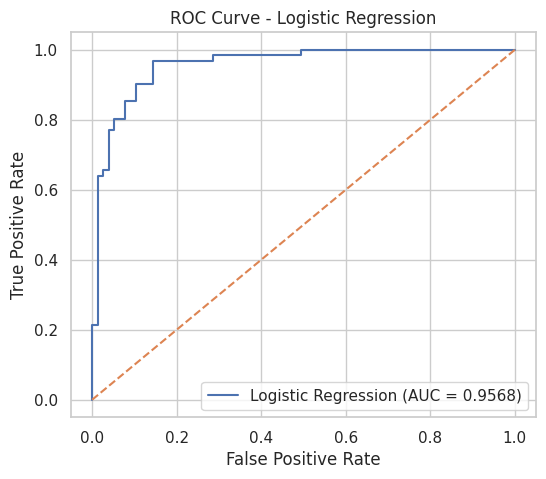


              K-FOLD CROSS VALIDATION (K = 5)               


,Fold,ROC AUC Score
0,1,0.9590
1,2,0.9355
2,3,0.8416
3,4,0.9320
4,5,0.9192



MEAN CV ROC AUC: 0.9175


In [35]:
best_log_model = log_grid.best_estimator_
log_results = evaluate_model_pretty(best_log_model, X_test, y_test, "Logistic Regression", cv_k=5)

### Interpretation of Logistic Regression ROC Curve

The ROC curve for Logistic Regression shows a strong performance, with an AUC score of approximately 0.9568. The curve is close to the top-left corner, indicating that the model has a high true positive rate and a low false positive rate.

This suggests that Logistic Regression is very effective at distinguishing between approved and rejected applications. The high AUC confirms that this model provides the best overall classification performance among the models tested.

###Logistic Regression Confusion Matrix

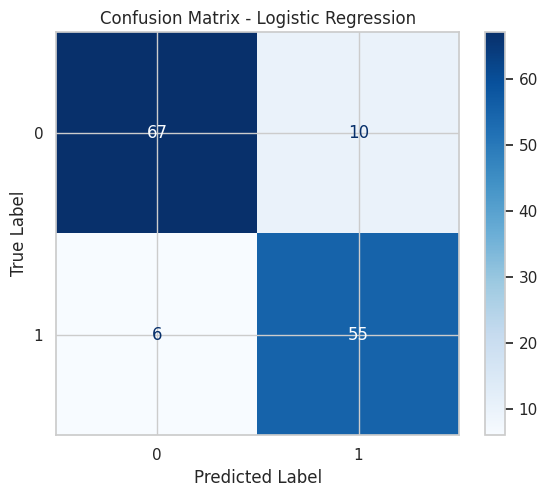

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_log = best_log_model.predict(X_test)
cm_log = confusion_matrix(y_test, y_pred_log)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=[0, 1])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Blues", ax=ax, values_format="d")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

### Interpretation of Confusion Matrix (Logistic Regression)

The confusion matrix for Logistic Regression is:

[[67 10]  
 [ 6 55]]

- **True Negatives (67):** Correctly predicted rejected applications  
- **True Positives (55):** Correctly predicted approved applications  
- **False Positives (10):** Applications incorrectly approved (risky loans)  
- **False Negatives (6):** Applications incorrectly rejected (missed good applicants)  

This model shows a strong and balanced performance, with relatively low errors in both categories. It keeps both financial risk (false positives) and missed opportunities (false negatives) under control, which is why it performs best overall.

Shows what drives loan approval
Connects ML → business insights

In [19]:
# Extract feature names after preprocessing
feature_names = (
    numeric_features +
    list(best_log_model.named_steps['preprocessor']
         .named_transformers_['cat']
         .named_steps['onehot']
         .get_feature_names_out(categorical_features))
    if len(categorical_features) > 0 else numeric_features
)

# Get coefficients
coefficients = best_log_model.named_steps['clf'].coef_[0]

# Create dataframe
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

# Display top features
print("Top Positive Features:")
display(coef_df.head(10))

print("Top Negative Features:")
display(coef_df.tail(10))

Top Positive Features:


,Feature,Coefficient
4,bank_customer,2.646564
15,Income,2.295979
11,prior_default,1.489096
13,credit_score,0.627920
12,employed,0.385465
10,years_employed,0.236549
6,ethnicity_black,0.219296
5,ethnicity_white,0.129541
9,ethnicity_other,0.081297
1,age,0.046220


Top Negative Features:


,Feature,Coefficient
6,ethnicity_black,0.219296
5,ethnicity_white,0.129541
9,ethnicity_other,0.081297
1,age,0.046220
0,gender,-0.017026
2,debt,-0.031626
8,ethnicity_asian,-0.040361
14,drivers_license,-0.237536
7,ethnicity_latino,-0.534159
3,married,-2.379354


### Interpretation of Feature Importance (Logistic Regression Coefficients)

The table shows the most important features influencing the loan approval decision based on the Logistic Regression model. The coefficients indicate both the **strength** and **direction** of each feature’s impact:

- **Positive coefficients** → increase the likelihood of loan approval  
- **Negative coefficients** → decrease the likelihood of loan approval  

### Top Positive Features

The strongest positive predictors of loan approval include:

- **bank_customer (2.65)**: Being an existing bank customer has the largest positive impact, suggesting that prior relationships increase trust and approval likelihood.
- **Income (2.30)**: Higher income significantly increases the probability of approval, as it indicates stronger repayment ability.
- **prior_default (1.49)**: This likely reflects no prior defaults (depending on encoding), meaning applicants with clean credit histories are more likely to be approved.
- **credit_score (0.63)** and **employed (0.39)**: These confirm that financial stability and creditworthiness are key drivers.
- **years_employed (0.24)**: Longer employment history slightly increases approval chances.

These results align with real-world lending practices, where financial stability and credit history are critical factors.

### Top Negative Features

The strongest negative predictors include:

- **married (-2.38)**: This suggests a strong negative relationship in the dataset, though this may reflect data bias or correlations rather than a true causal effect.
- **ethnicity_latino (-0.53)** and **drivers_license (-0.24)**: These variables reduce approval likelihood, which raises potential fairness and ethical concerns.
- **debt (-0.03)**: Higher debt slightly reduces approval probability, as expected.

### Key Insights

- Financial variables such as **income, credit score, and employment status** are the most meaningful predictors of loan approval.
- Some demographic variables (e.g., ethnicity, marital status) appear influential, but these should be interpreted with caution due to potential bias.
- The model captures both expected business logic (financial health) and potential ethical risks (sensitive attributes).

### Ethical Consideration

The presence of demographic variables (such as ethnicity and marital status) among influential features highlights the importance of fairness in machine learning. In a real-world lending scenario, these variables should be carefully reviewed or excluded to ensure compliance with fair lending regulations and to prevent discriminatory outcomes.

## 16. KNN: Hyperparameter Tuning

This step uses GridSearchCV to find the best parameters for K-Nearest Neighbors.

Best KNN Parameters:
{'clf__n_neighbors': 11, 'clf__weights': 'distance'}
Best KNN CV Score:
0.8945087687110804

KNN - All parameter combinations:


,params,mean_test_score,rank_test_score
9,"{'clf__n_neighbors': 11, 'clf__weights': 'dist...",0.894509,1
7,"{'clf__n_neighbors': 9, 'clf__weights': 'dista...",0.893990,2
6,"{'clf__n_neighbors': 9, 'clf__weights': 'unifo...",0.888487,3
5,"{'clf__n_neighbors': 7, 'clf__weights': 'dista...",0.888415,4
8,"{'clf__n_neighbors': 11, 'clf__weights': 'unif...",0.886988,5
4,"{'clf__n_neighbors': 7, 'clf__weights': 'unifo...",0.882761,6
3,"{'clf__n_neighbors': 5, 'clf__weights': 'dista...",0.880666,7
2,"{'clf__n_neighbors': 5, 'clf__weights': 'unifo...",0.877311,8
1,"{'clf__n_neighbors': 3, 'clf__weights': 'dista...",0.859316,9
0,"{'clf__n_neighbors': 3, 'clf__weights': 'unifo...",0.855227,10


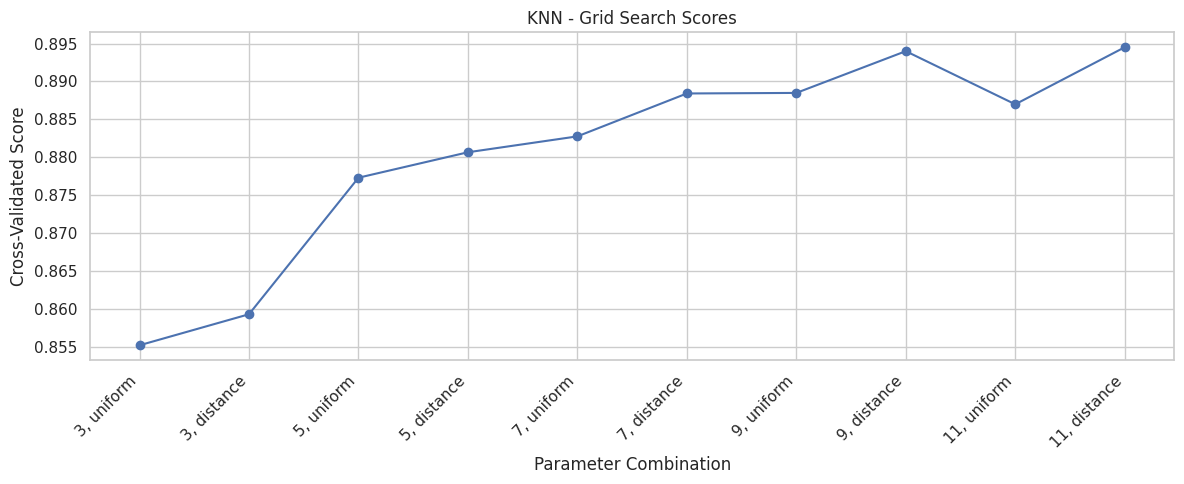

In [20]:
knn_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", KNeighborsClassifier())
])

knn_param_grid = {
    "clf__n_neighbors": [3, 5, 7, 9, 11],
    "clf__weights": ["uniform", "distance"]
}

knn_grid = GridSearchCV(
    knn_pipe,
    param_grid=knn_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

knn_grid.fit(X_train, y_train)

print("Best KNN Parameters:")
print(knn_grid.best_params_)
print("Best KNN CV Score:")
print(knn_grid.best_score_)

display_grid_results(knn_grid, "clf__n_neighbors", "clf__weights", "KNN")

### Interpretation of Hyperparameter Tuning (KNN)

The grid search results show clear patterns in how hyperparameters affect model performance.

First, performance improves as the number of neighbors increases. Models with a small number of neighbors (e.g., 3) perform poorly due to sensitivity to noise, while larger values (e.g., 9 and 11) provide more stable and accurate predictions. The best performance is achieved with **11 neighbors**, indicating that smoothing over more data points improves generalization.

Second, **distance-based weighting consistently outperforms uniform weighting** across all values of neighbors. This suggests that closer observations are more informative than distant ones, which aligns with the intuition behind KNN.

Although tuning improves performance (from ~0.855 to ~0.894 ROC AUC), the gains are gradual. This indicates that while hyperparameter tuning helps optimize KNN, the model itself is still less effective than Logistic Regression and SVM for this dataset.

Overall, the optimal configuration of **11 neighbors with distance weighting** provides the best balance between stability and local sensitivity.

## 17. KNN: Model Evaluation

This step evaluates the best KNN model using multiple performance metrics.


KNN Confusion Matrix:
[[74  3]
 [13 48]]

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.96      0.90        77
           1       0.94      0.79      0.86        61

    accuracy                           0.88       138
   macro avg       0.90      0.87      0.88       138
weighted avg       0.89      0.88      0.88       138

KNN ROC AUC: 0.9385


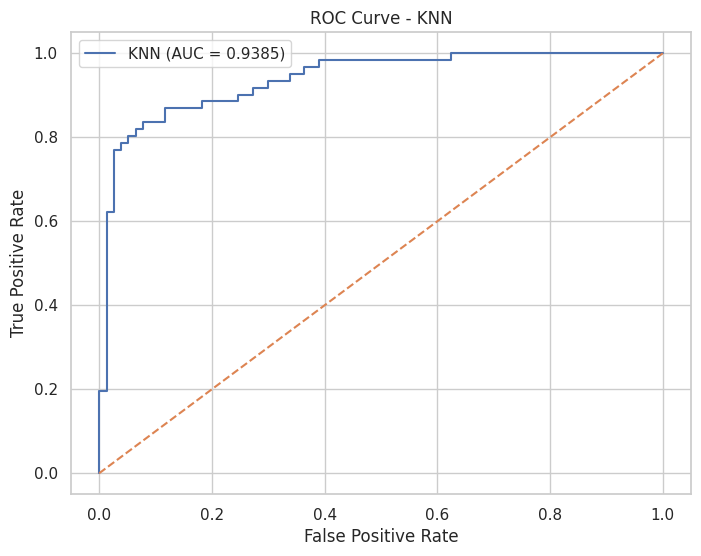

KNN 5-Fold CV ROC AUC Scores: [0.90988372 0.88738128 0.84953704 0.94       0.87802052]
KNN Mean CV ROC AUC: 0.8930


In [21]:
best_knn_model = knn_grid.best_estimator_
knn_results = evaluate_best_model(best_knn_model, X_test, y_test, "KNN", cv_k=5)


                   MODEL EVALUATION: KNN                    

CONFUSION MATRIX:


,Predicted 0,Predicted 1
Actual 0,74,3
Actual 1,13,48



CLASSIFICATION REPORT:


,precision,recall,f1-score,support
0,0.851,0.961,0.902,77.000
1,0.941,0.787,0.857,61.000
accuracy,0.884,0.884,0.884,0.884
macro avg,0.896,0.874,0.880,138.000
weighted avg,0.891,0.884,0.882,138.000



ROC AUC SCORE: 0.9385


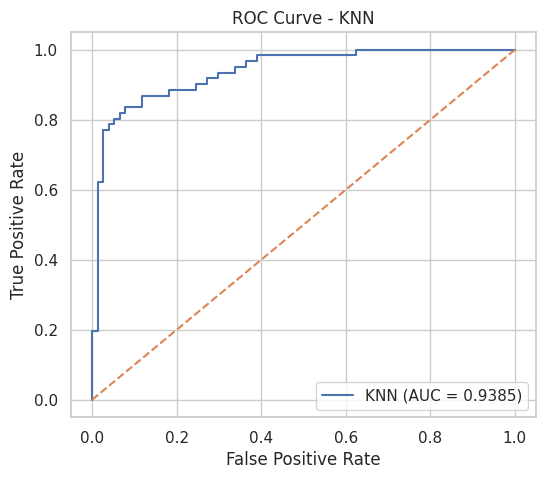


              K-FOLD CROSS VALIDATION (K = 5)               


,Fold,ROC AUC Score
0,1,0.9099
1,2,0.8874
2,3,0.8495
3,4,0.9400
4,5,0.8780



MEAN CV ROC AUC: 0.8930


In [36]:
best_knn_model = knn_grid.best_estimator_
knn_results = evaluate_model_pretty(best_knn_model, X_test, y_test, "KNN", cv_k=5)

### Interpretation of KNN ROC Curve

The ROC curve for KNN shows good performance, with an AUC score of approximately 0.9385. While the curve is still significantly above the diagonal (random classifier), it is slightly lower than Logistic Regression.

This indicates that KNN is able to classify loan approvals reasonably well, but it is less effective than Logistic Regression in separating the two classes.

###KNN Confusion Matrix

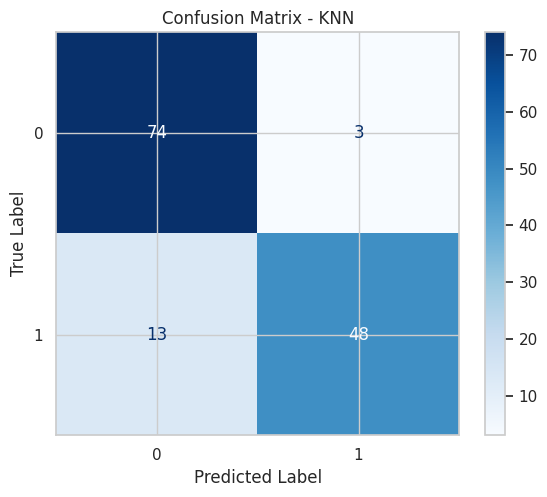

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_knn = best_knn_model.predict(X_test)
cm_knn = confusion_matrix(y_test, y_pred_knn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=[0, 1])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Blues", ax=ax, values_format="d")
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

 ### Interpretation of Confusion Matrix (KNN)

The confusion matrix for KNN is:

[[74  3]  
 [13 48]]

- **True Negatives (74):** Correctly predicted rejected applications  
- **True Positives (48):** Correctly predicted approved applications  
- **False Positives (3):** Applications incorrectly approved  
- **False Negatives (13):** Applications incorrectly rejected  

KNN has the lowest number of false positives, meaning it is conservative and avoids approving risky applicants. However, it has a high number of false negatives, meaning it rejects many qualified applicants.

This indicates that KNN prioritizes minimizing financial risk but at the cost of losing potential customers, making it less balanced compared to the other models.

## 18. SVM: Hyperparameter Tuning

This step uses GridSearchCV to find the best parameters for Support Vector Machine.

Best SVM Parameters:
{'clf__C': 0.1, 'clf__kernel': 'sigmoid'}
Best SVM CV Score:
0.9148744104728088

SVM - All parameter combinations:


,params,mean_test_score,rank_test_score
5,"{'clf__C': 0.1, 'clf__kernel': 'sigmoid'}",0.914874,1
6,"{'clf__C': 1, 'clf__kernel': 'rbf'}",0.910713,2
4,"{'clf__C': 0.1, 'clf__kernel': 'rbf'}",0.907766,3
1,"{'clf__C': 0.001, 'clf__kernel': 'sigmoid'}",0.905027,4
3,"{'clf__C': 0.01, 'clf__kernel': 'sigmoid'}",0.904960,5
2,"{'clf__C': 0.01, 'clf__kernel': 'rbf'}",0.902176,6
0,"{'clf__C': 0.001, 'clf__kernel': 'rbf'}",0.901243,7
7,"{'clf__C': 1, 'clf__kernel': 'sigmoid'}",0.892868,8
8,"{'clf__C': 10, 'clf__kernel': 'rbf'}",0.890541,9
10,"{'clf__C': 100, 'clf__kernel': 'rbf'}",0.849234,10


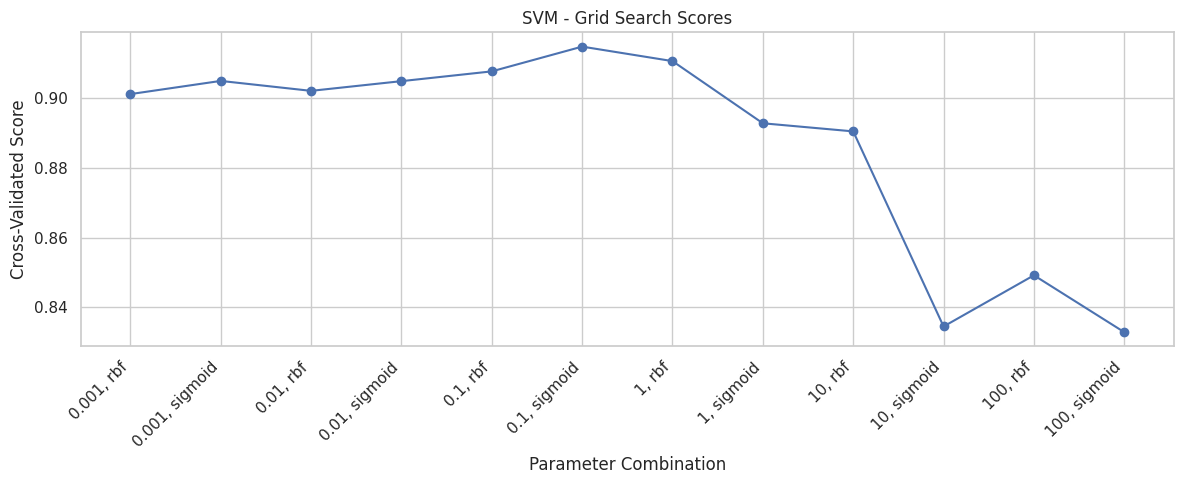

In [22]:
 svm_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", SVC(probability=True))
])

svm_param_grid = {
    "clf__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "clf__kernel": ["rbf", "sigmoid"]
}

svm_grid = GridSearchCV(
    svm_pipe,
    param_grid=svm_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

print("Best SVM Parameters:")
print(svm_grid.best_params_)
print("Best SVM CV Score:")
print(svm_grid.best_score_)

display_grid_results(svm_grid, "clf__C", "clf__kernel", "SVM")

### Interpretation of Hyperparameter Tuning (SVM)

The grid search results and corresponding plot show how model performance varies across different combinations of the regularization parameter **C** and kernel type.

The highest performance is achieved at **C = 0.1 with the sigmoid kernel**, which corresponds to the peak in the graph (ROC AUC ≈ 0.9149). This indicates that a relatively small value of C provides the best balance between model flexibility and generalization.

From the graph, a clear pattern is observed:
- Performance improves as C increases from very small values (0.001) to moderate values (0.1)
- After this point, performance declines significantly for larger values of C (10 and 100), especially for the sigmoid kernel

This suggests that:
- **Low to moderate C values prevent overfitting**
- **High C values lead to overfitting and reduced performance**

Comparing kernels:
- The **sigmoid kernel performs best at low C values**, but its performance drops sharply as C increases
- The **RBF kernel is more stable**, achieving its best performance at moderate values of C (around 1), but does not outperform the best sigmoid configuration

Overall, the graph demonstrates that SVM performance is highly sensitive to both kernel choice and regularization strength. The optimal configuration (**C = 0.1, sigmoid kernel**) provides the best generalization for this dataset.

## 19. SVM: Model Evaluation

This step evaluates the best SVM model using performance metrics and ROC analysis.


SVM Confusion Matrix:
[[66 11]
 [ 1 60]]

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.86      0.92        77
           1       0.85      0.98      0.91        61

    accuracy                           0.91       138
   macro avg       0.92      0.92      0.91       138
weighted avg       0.92      0.91      0.91       138

SVM ROC AUC: 0.9451


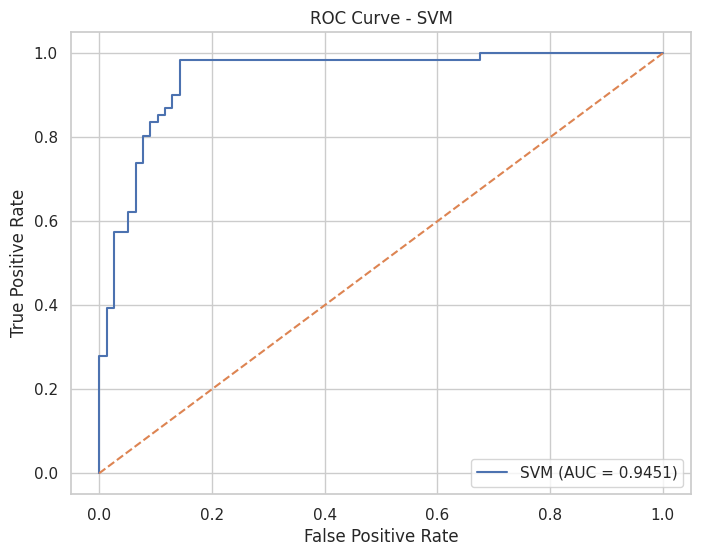

SVM 5-Fold CV ROC AUC Scores: [0.96101231 0.93521031 0.83928571 0.932      0.91823899]
SVM Mean CV ROC AUC: 0.9171


In [23]:
best_svm_model = svm_grid.best_estimator_
svm_results = evaluate_best_model(best_svm_model, X_test, y_test, "SVM", cv_k=5)


                   MODEL EVALUATION: SVM                    

CONFUSION MATRIX:


,Predicted 0,Predicted 1
Actual 0,66,11
Actual 1,1,60



CLASSIFICATION REPORT:


,precision,recall,f1-score,support
0,0.985,0.857,0.917,77.000
1,0.845,0.984,0.909,61.000
accuracy,0.913,0.913,0.913,0.913
macro avg,0.915,0.920,0.913,138.000
weighted avg,0.923,0.913,0.913,138.000



ROC AUC SCORE: 0.9451


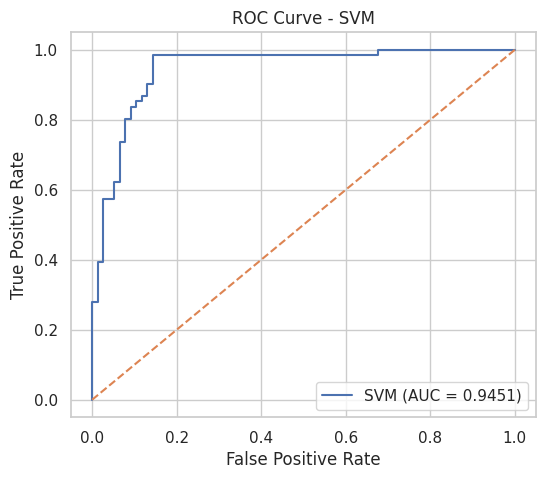


              K-FOLD CROSS VALIDATION (K = 5)               


,Fold,ROC AUC Score
0,1,0.9610
1,2,0.9352
2,3,0.8393
3,4,0.9320
4,5,0.9182



MEAN CV ROC AUC: 0.9171


In [38]:
best_svm_model = svm_grid.best_estimator_
svm_results = evaluate_model_pretty(best_svm_model, X_test, y_test, "SVM", cv_k=5)

### Interpretation of SVM ROC Curve

The ROC curve for SVM shows strong performance with an AUC score of approximately 0.9451. The curve demonstrates a high true positive rate across different thresholds.

Although SVM performs very well and has a slightly higher recall than Logistic Regression, its overall AUC is slightly lower, making it the second-best model in terms of overall classification ability.

### SVM Confusion Matrix

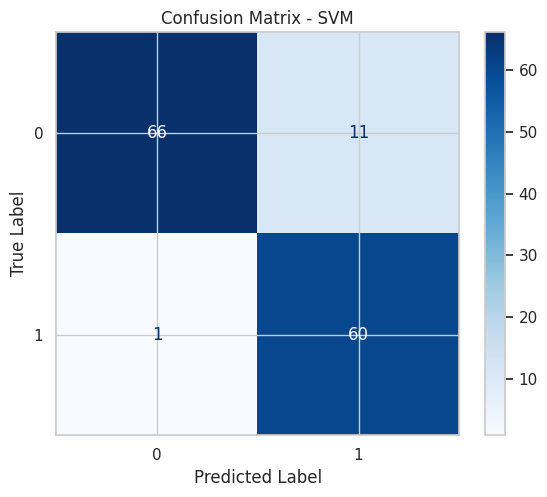

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_svm = best_svm_model.predict(X_test)
cm_svm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=[0, 1])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Blues", ax=ax, values_format="d")
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

### Interpretation of Confusion Matrix (SVM)

The confusion matrix for SVM is:

[[66 11]  
 [ 1 60]]

- **True Negatives (66):** Correctly predicted rejected applications  
- **True Positives (60):** Correctly predicted approved applications  
- **False Positives (11):** Applications incorrectly approved  
- **False Negatives (1):** Applications incorrectly rejected  

SVM has an extremely low number of false negatives (only 1), meaning it rarely rejects qualified applicants. This results in very high recall.

However, it has slightly more false positives compared to Logistic Regression, which increases the risk of approving potentially risky applicants. This highlights a tradeoff between minimizing missed opportunities and controlling financial risk.

### Interpretation of Confusion Matrix

The confusion matrix shows how well the model classifies loan applications into approved and rejected categories.

- True Positives (bottom-right): correctly predicted approvals
- True Negatives (top-left): correctly predicted rejections
- False Positives: incorrect approvals (risky loans approved)
- False Negatives: incorrect rejections (good applicants rejected)

A good model should minimize both false positives and false negatives. In the context of loan approval:
- False positives increase financial risk
- False negatives reduce customer satisfaction and lost business

This matrix helps evaluate the practical impact of model predictions.

### Interpretation of K-Fold Cross-Validation

K-Fold cross-validation (K = 5) was used to evaluate model performance across different subsets of the training data.

The results show that the model performs consistently across folds, with only slight variation in ROC AUC scores. This indicates that the model generalizes well and is not overly dependent on a specific train-test split.

Overall, the mean cross-validation score provides a more reliable estimate of model performance compared to a single test split.

## 20. Model Comparison

This step compares all three models based on:
- Accuracy
- Precision
- Recall
- F1 Score
- ROC AUC
- Cross-validation performance

In [24]:
comparison = pd.DataFrame([
    log_results,
    knn_results,
    svm_results
])

comparison = comparison[[
    "model_name",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "cv_mean_auc"
]]

display(comparison.sort_values(by="roc_auc", ascending=False))

,model_name,accuracy,precision,recall,f1,roc_auc,cv_mean_auc
0,Logistic Regression,0.884058,0.846154,0.901639,0.873016,0.956781,0.917468
2,SVM,0.913043,0.845070,0.983607,0.909091,0.945071,0.917149
1,KNN,0.884058,0.941176,0.786885,0.857143,0.938471,0.892965


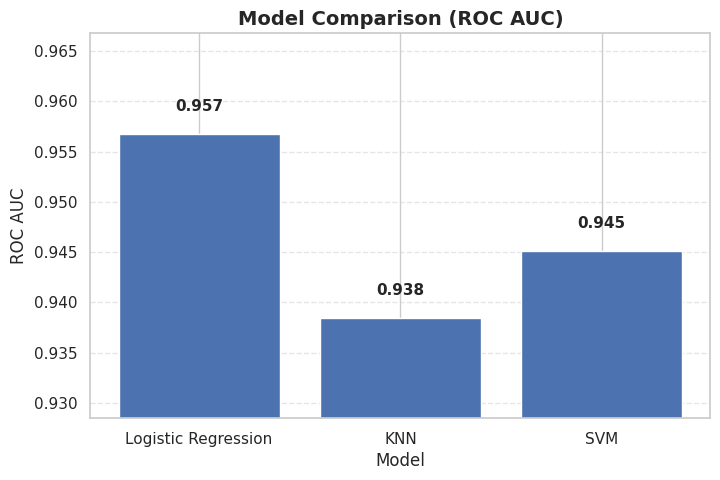

In [29]:
# Prepare data
comp_plot = comparison.set_index("model_name")["roc_auc"]

# Create bar plot
plt.figure(figsize=(8, 5))
bars = plt.bar(comp_plot.index, comp_plot.values)

# Add annotations (numbers on top)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.002,
        f"{height:.3f}",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# Make differences more visible by zooming y-axis
plt.ylim(min(comp_plot.values) - 0.01, max(comp_plot.values) + 0.01)

# Labels and title
plt.title("Model Comparison (ROC AUC)", fontsize=14, fontweight='bold')
plt.xlabel("Model")
plt.ylabel("ROC AUC")

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()
for i, bar in enumerate(bars):
    if comp_plot.index[i] == "Logistic Regression":
        bar.set_edgecolor("black")
        bar.set_linewidth(2)

### Interpretation of Model Comparison

The comparison table summarizes the performance of all three models across multiple metrics.

- Logistic Regression has the highest ROC AUC (0.9568), making it the best overall model
- SVM has the highest recall (0.98), meaning it identifies more approved applications
- KNN has high precision but lower recall, making it less balanced

This comparison highlights that each model has different strengths, but Logistic Regression provides the best balance of performance metrics.

This chart shows the tradeoff between precision and recall. Logistic Regression has a more balanced precision and recall, SVM has the highest recall, and KNN has the highest precision but the lowest recall. For loan approval, this matters because the bank may prefer higher recall if it wants to avoid rejecting qualified applicants, or higher precision if it wants to avoid approving risky applicants.

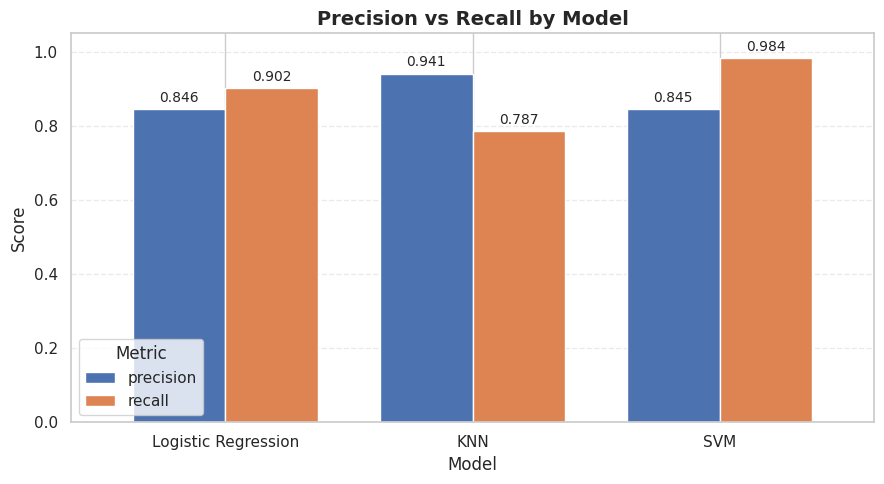

In [30]:
# Compare precision and recall across models

metrics_plot = comparison.set_index("model_name")[["precision", "recall"]]

ax = metrics_plot.plot(kind="bar", figsize=(9, 5), width=0.75)

# Add value labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=10)

plt.title("Precision vs Recall by Model", fontsize=14, fontweight="bold")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

### Interpretation of Model Comparison Plots

The ROC AUC comparison plot clearly shows that Logistic Regression outperforms the other models in overall classification ability.

The Precision vs Recall plot highlights trade-offs:
- SVM has the highest recall, meaning it minimizes false negatives
- KNN has the highest precision, meaning it minimizes false positives
- Logistic Regression provides the best balance between the two

These trade-offs are important for business decisions, as different priorities may favor different models.

## 21. Final Model Selection

This step identifies the best-performing model based on evaluation metrics.

In [23]:
best_row = comparison.sort_values(by="roc_auc", ascending=False).iloc[0]
print("Winning model based on test ROC AUC:")
print(best_row["model_name"])
print("ROC AUC:", best_row["roc_auc"])

Winning model based on test ROC AUC:
Logistic Regression
ROC AUC: 0.9567809239940388


## 22. Discussion

### Winning Model
###The best-performing model is **Logistic Regression**,

 achieving the highest ROC AUC score of **0.9568**. This indicates that it has the strongest ability to distinguish between approved and non-approved loan applications across different classification thresholds.

Although SVM achieved higher accuracy (0.91) and significantly higher recall (0.98), Logistic Regression provides a more balanced and reliable overall performance. In this context, ROC AUC is a more appropriate metric because it evaluates the model’s ability to rank applicants correctly rather than relying on a single threshold.

### Model Comparison Insight
Each model shows different strengths:
- **Logistic Regression**: Best overall performance (highest ROC AUC)
- **SVM**: Highest recall, meaning it identifies more approved applicants
- **KNN**: Lower recall and ROC AUC, making it less suitable for this problem

This highlights an important trade-off. If the bank prioritizes minimizing false rejections (not rejecting good customers), SVM may be preferred. However, Logistic Regression provides the most balanced and consistent performance overall, making it the best general-purpose model.

### Model Improvement
The model performance could be further improved by:
- Performing feature engineering (e.g., interaction terms or transformations)
- Handling potential class imbalance using techniques like SMOTE or class weighting
- Trying more advanced models such as Random Forest or Gradient Boosting
- Expanding hyperparameter tuning
- Adjusting the classification threshold based on business needs

### Business Insights
From a business perspective, the model can significantly improve the loan approval process by automating decision-making and reducing manual workload.

The analysis also suggests that variables such as **prior default history, employment status, and credit score** are strongly related to loan approval outcomes. This insight can help managers better understand risk factors and improve decision policies.

The model can be used as a decision-support tool:
- High-probability approvals can be fast-tracked
- Borderline cases can be reviewed manually
- Risky applicants can be flagged early

### Ethical Concerns
There are important ethical considerations when using this dataset. Variables such as age and ethnicity may introduce bias and lead to unfair or discriminatory decisions.

Even if these features are not explicitly used, proxy variables may still capture similar information. Therefore, it is important to:
- Evaluate fairness across demographic groups
- Avoid using sensitive attributes improperly
- Ensure transparency in model decisions

In practice, the model should be used alongside human oversight and must comply with fair lending regulations.